In [46]:
import pandas as pd
import numpy as np

import pickle

from matplotlib import pyplot as plt

from tuner import Tuner

from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import r2_score

import ast
from sklearn.preprocessing import MultiLabelBinarizer


In [42]:
def ensure_list_column(column):
    """
    Converts a pandas Series column into lists.

    Rules:
    - List-like strings (e.g. "['a', 'b']") -> actual lists
    - Plain strings (e.g. "hello") -> ["hello"]
    - Existing lists remain unchanged
    - NaN values become []
    """

    def convert(x):

        # Handle NaN
        if pd.isna(x):
            return []

        # Already a list
        if isinstance(x, list):
            return x

        # Try parsing list-like strings
        if isinstance(x, str):
            try:
                parsed = ast.literal_eval(x)

                # If parsed result is a list, return it
                if isinstance(parsed, list):
                    return parsed

            except (ValueError, SyntaxError):
                pass

            # Plain string fallback
            return [x]

        # Any other datatype
        return [x]

    return column.apply(convert)

In [43]:
full = pd.read_csv('../../pickle-object/balance_final_svd_table_all.csv')

In [44]:
full.rename(columns={'Name':'name'}, inplace=True)
full['Category'] = ensure_list_column(full['Category'])
full['Mechanics'] = ensure_list_column(full['Mechanics'])

In [48]:
mlb = MultiLabelBinarizer()

encoded = pd.DataFrame(
    mlb.fit_transform(full["Category"]),
    columns=mlb.classes_,
    index=full.index
)
full = full.drop('Category', axis=1)
full = pd.concat([full, encoded], axis=1)

In [49]:
mlb = MultiLabelBinarizer()

encoded = pd.DataFrame(
    mlb.fit_transform(full["Mechanics"]),
    columns=mlb.classes_,
    index=full.index
)
full = full.drop('Mechanics', axis=1)
full = pd.concat([full, encoded], axis=1)

In [50]:
full.head()

,name,Description,Average Score,Number of Reviews,SV_1,SV_2,SV_3,SV_4,SV_5,SV_6,...,Turn Order: Stat-Based,Variable Phase Order,Variable Player Powers,Variable Set-up,Victory Points as a Resource,Voting,Worker Placement,Worker Placement with Dice Workers,"Worker Placement, Different Worker Types",Zone of Control
0,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...,1.31,31,0.301526,-0.209281,0.343165,0.176303,-0.364879,0.748866,...,0,0,0,0,0,0,0,0,0,0
1,Oneupmanship: Mine's Bigger,"&quot;Show me a good loser, and I'll show you ...",1.04,75,0.206572,-0.123297,0.203228,-0.626003,0.649891,0.279944,...,0,0,0,0,0,0,0,0,0,0
2,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...,1.31,31,0.301526,-0.209281,0.343165,0.176303,-0.364879,0.748866,...,0,0,0,0,0,0,0,0,0,0
3,Rock Paper Scissors Game,Pressman takes the classic game and puts it in...,1.31,31,0.301526,-0.209281,0.343165,0.176303,-0.364879,0.748866,...,0,0,0,0,0,0,0,0,0,0
4,Oneupmanship: Mine's Bigger,"&quot;Show me a good loser, and I'll show you ...",1.04,75,0.206572,-0.123297,0.203228,-0.626003,0.649891,0.279944,...,0,0,0,0,0,0,0,0,0,0


In [52]:
X = full.iloc[:, 4:]
y = full['Average Score']

In [56]:
round(y).value_counts()

Average Score
8.0     1114
4.0     1092
6.0     1090
2.0     1066
7.0     1063
1.0     1020
5.0      968
3.0      933
10.0     831
9.0      823
Name: count, dtype: int64

In [57]:
tuner = Tuner(X, y)

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [59]:
y_baseline = np.full_like(y, fill_value=np.mean(y))
rmse_baseline = np.sqrt(mean_squared_error(y, y_baseline))
rmse_baseline

np.float64(2.7061667333066537)

In [60]:
def bin_score(X, y, model, mapping_fn=round):
    """
    Evaluate a regression model, then bin outputs for classification-style accuracy.

    Parameters:
    -----------
    X : array-like
        Features
    y : array-like
        True continuous targets
    model : sklearn-like model
        Must implement .fit() and .predict()
    mapping_fn : function
        Function that maps continuous values → categorical bins
        Should work on numpy arrays

    Returns:
    --------
    dict with:
        - rmse
    """
    y_pred = model.predict(X)

    y_binned = y.apply(mapping_fn)
    y_pred_binned = pd.Series(y_pred).apply(mapping_fn)
    
    rmse = np.sqrt(mean_squared_error(y, y_pred))

    return float(rmse)

In [61]:
def build_conf_matrix(clf, X_test, y_test):
    y_pred = clf.predict(X_test)
    cm = confusion_matrix(round(y_test), round(pd.Series(data=y_pred)))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[i for i in range(1,11)])
    disp.plot(cmap=plt.cm.Blues)
    pass

In [62]:
def pred_actual(clf, X_text, y_test, bin=False):
    y_pred = clf.predict(X_test)
    
    if bin:
        y_test = round(pd.Series(data=y_test))
        y_pred = round(pd.Series(data=y_pred))

    r2 = r2_score(y_test, y_pred)
    
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, y_pred, color='blue', label='Predictions')
    
    max_val = max(max(y_test), max(y_pred))
    min_val = min(min(y_test), min(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Fit')
    
    plt.text(min_val, max_val, f'$R^2 = {r2:.3f}$', fontsize=12, verticalalignment='top')
    
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Predicted vs. Actual Plot')
    plt.legend()
    plt.grid(True)
    plt.show()

    pass

# KNN Regressor

In [63]:
tuner.tune(KNeighborsRegressor,
           10,
           0.25,
           'n_neighbors',
           range(1,15),
           {},
           bin_score,
           True
          )

In [64]:
tuner.results

,tune_id,classifier,hyperparameter,best_hyperparameter_setting,train_score,test_score
0,17780553828,KNeighborsRegressor,n_neighbors,3,0.650797,0.976953


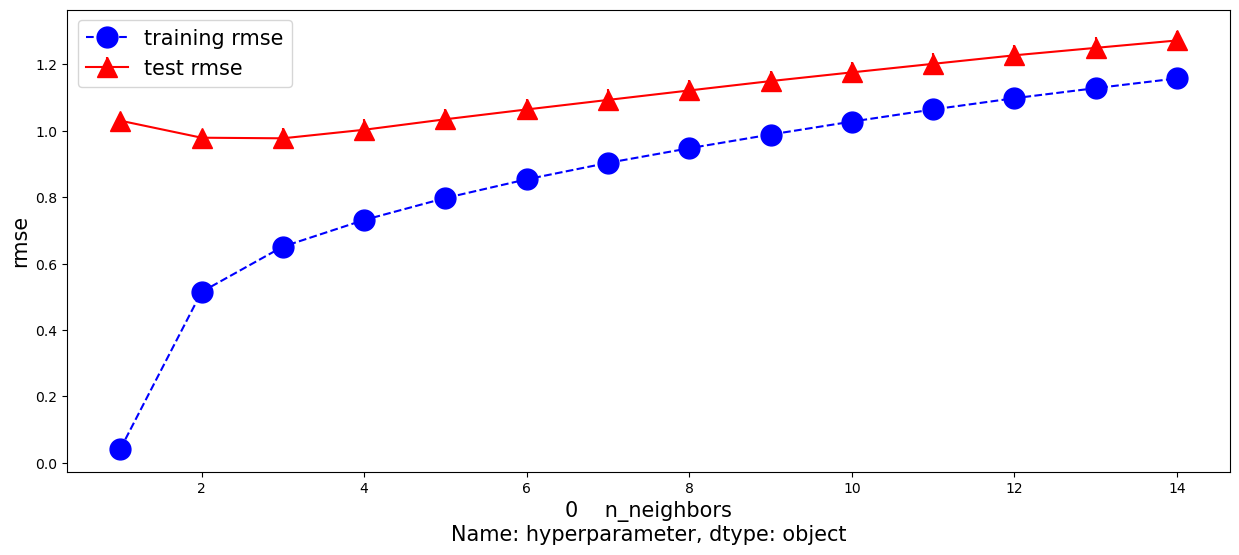

In [66]:
tuner.plot_hyperparameter_tuning(17780553828, metric_name='rmse')

In [73]:
knn_reg = KNeighborsRegressor(n_neighbors=3)
knn_reg.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


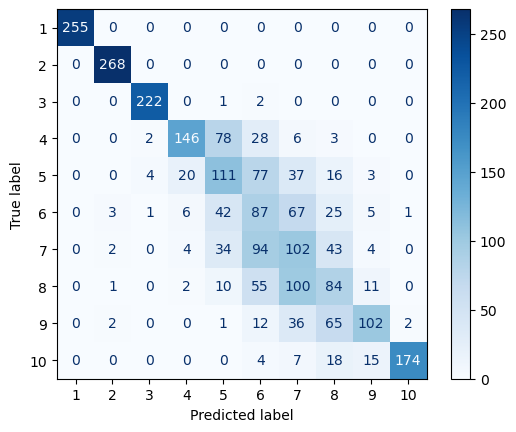

In [74]:
build_conf_matrix(knn_reg, X_test, y_test)

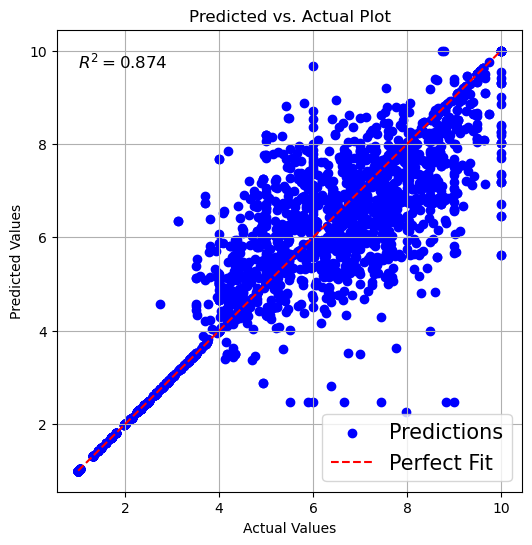

In [75]:
pred_actual(knn_reg, X_test, y_test, False)

In [78]:
score = bin_score(X_test, y_test, knn_reg)
(rmse_baseline - score)

np.float64(1.7387213114256834)

# Lasso and Ridge

In [79]:
from sklearn.linear_model import Lasso, Ridge

In [81]:
lasso_params = [1e-5, 1e-4, 1e-3,
                7e-3, 1e-2, 5e-2,
                0.1, 0.2, 0.4,
                0.75, 1, 1.5]

In [ ]:
tuner.tune(Lasso,
           10,
           0.25,
           'alpha',
           lasso_params,
           {'max_iter': 100000},
           bin_score,
           True)

In [ ]:
tuner.tune(Ridge,
           10,
           0.25,
           'alpha',
           lasso_params,
           {'max_iter': 100000},
           bin_score,
           True)

In [126]:
tuner.results

,tune_id,classifier,hyperparameter,best_hyperparameter_setting,test_score,train_score
0,17779855102,KNeighborsRegressor,n_neighbors,2.0000,0.466910,0.906025
1,17779861469,Lasso,alpha,0.0001,0.709631,0.981221
2,17779865874,Ridge,alpha,0.4000,0.690674,0.960369


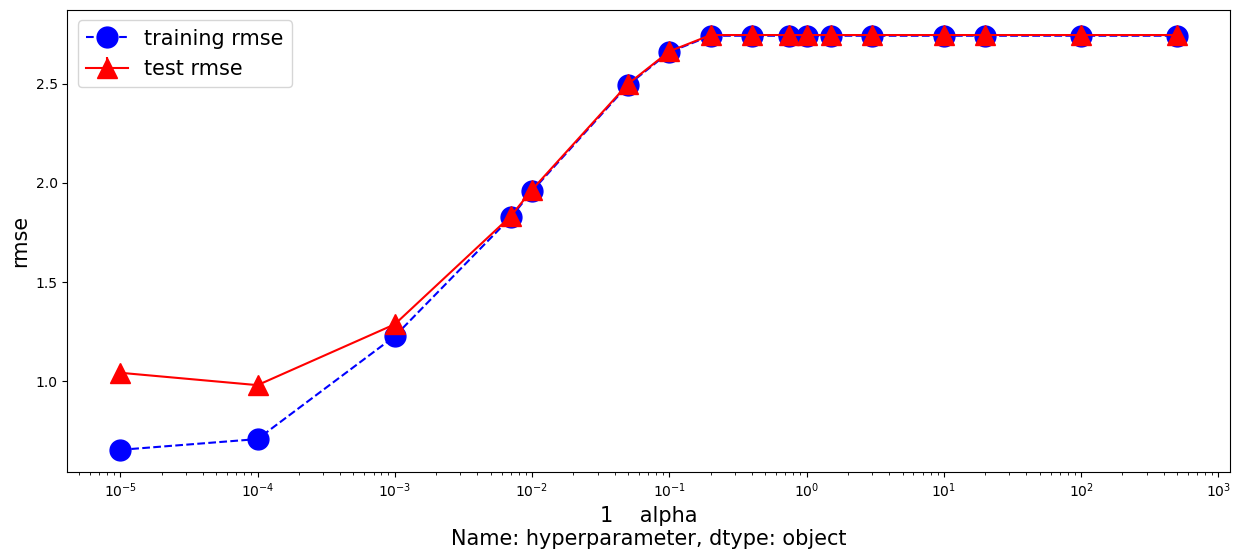

In [134]:
tuner.plot_hyperparameter_tuning(17779861469, True, metric_name='rmse')

In [135]:
lasso_reg = Lasso(alpha=0.0001)
lasso_reg.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


1.0525798626021974


ValueError: The number of FixedLocator locations (11), usually from a call to set_ticks, does not match the number of labels (10).

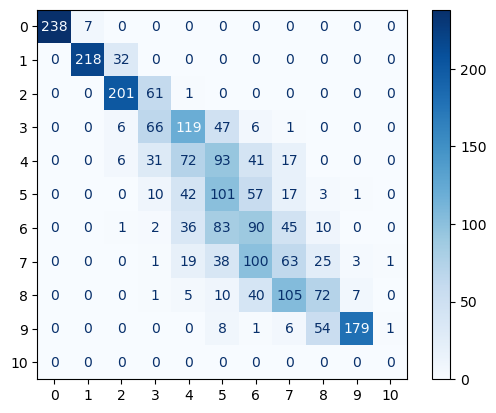

In [142]:
build_conf_matrix(lasso_reg, X_test, y_test)

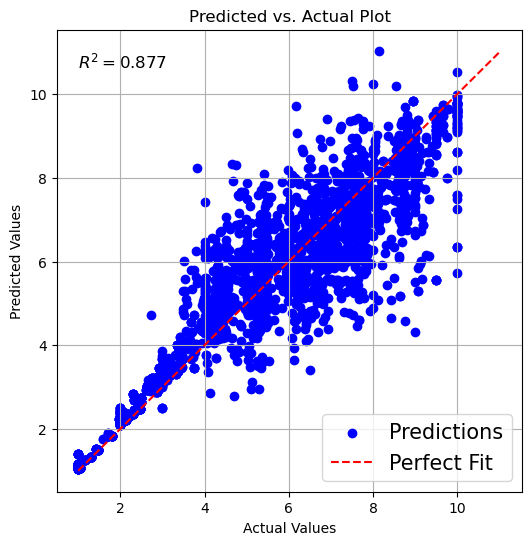

In [140]:
pred_actual(lasso_reg, X_test, y_test, False)

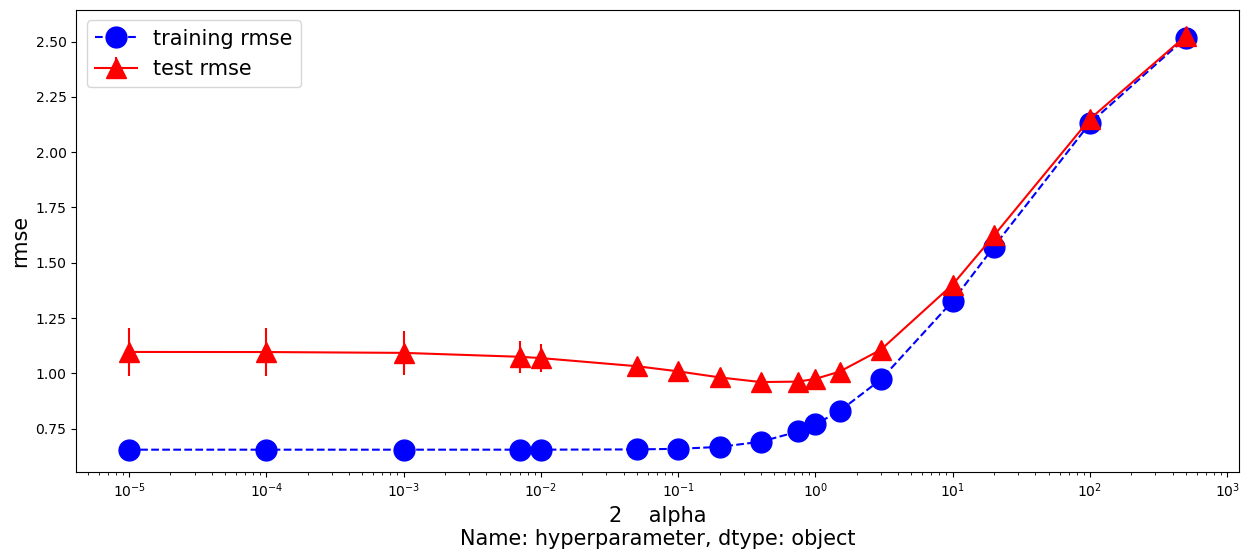

In [159]:
tuner.plot_hyperparameter_tuning(17779865874, True, metric_name='rmse')

In [145]:
ridge_reg = Ridge(alpha=0.4000)
ridge_reg.fit(X_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",0.4
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


ValueError: The number of FixedLocator locations (11), usually from a call to set_ticks, does not match the number of labels (10).

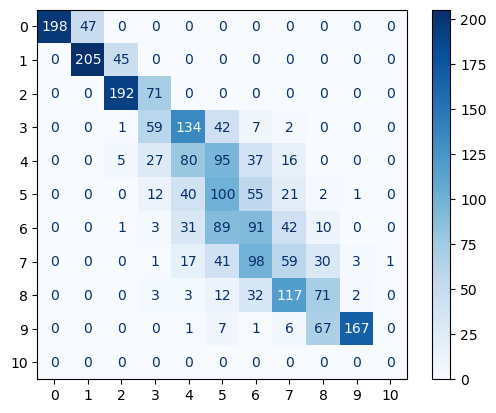

In [156]:
build_conf_matrix(ridge_reg, X_test, y_test)

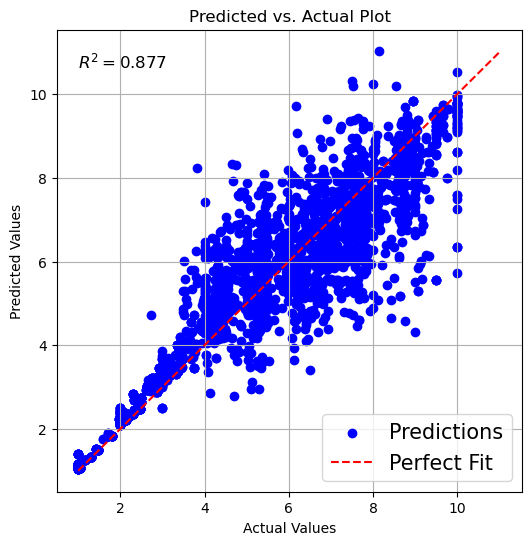

In [146]:
pred_actual(ridge_reg, X_test, y_test, False)

In [130]:
from sklearn.ensemble import RandomForestRegressor

In [131]:
rfr_settings = {}

In [ ]:
tuner.tune(RandomForestRegressor,
           10,
           0.25,
           'max_depth',
           range(2,6),
           {'random_state': 42},
           bin_score,
           True)

In [147]:
from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
tuner.tune(GradientBoostingRegressor,
           10,
           0.25,
           'max_depth',
           range(2,6),
           {'random_state': 42},
           bin_score,
           True)

In [160]:
g_boost = GradientBoostingRegressor(max_depth=1)
g_boost.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",1
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

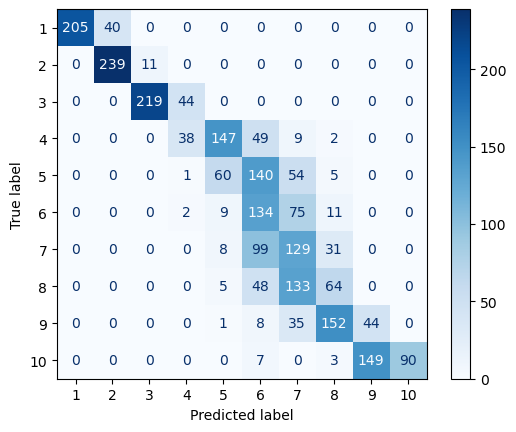

In [154]:
build_conf_matrix(g_boost, X_test, y_test)

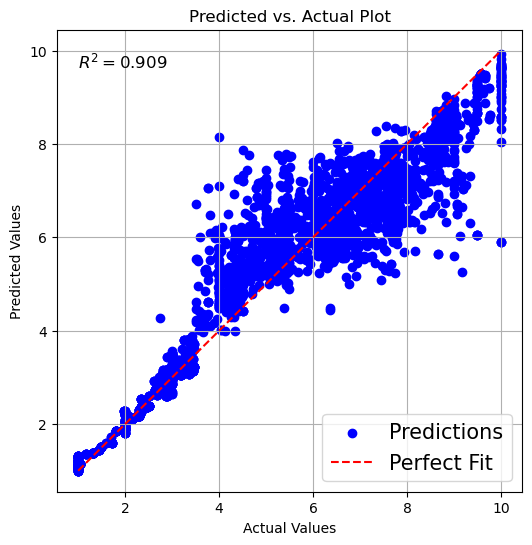

In [155]:
pred_actual(g_boost, X_test, y_test, False)

In [152]:
tuner.results

,tune_id,classifier,hyperparameter,best_hyperparameter_setting,test_score,train_score
0,17779855102,KNeighborsRegressor,n_neighbors,2.0000,0.466910,0.906025
1,17779861469,Lasso,alpha,0.0001,0.709631,0.981221
2,17779865874,Ridge,alpha,0.4000,0.690674,0.960369
3,17780029002,GradientBoostingRegressor,max_depth,5.0000,0.504355,0.824458


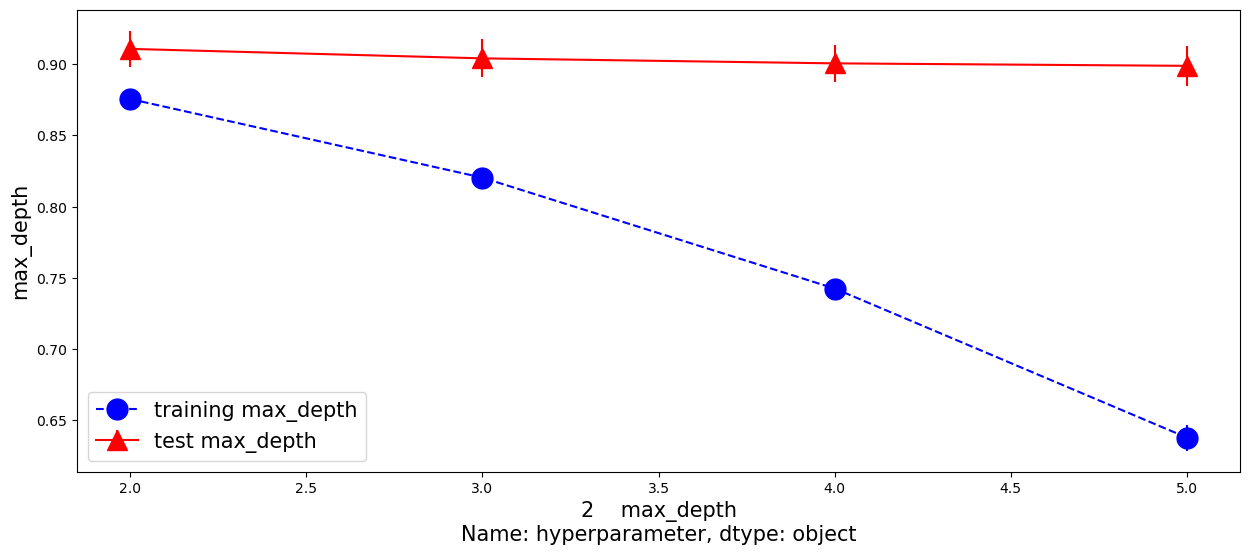

In [73]:
tuner.plot_hyperparameter_tuning(17779454294, metric_name='max_depth')

In [ ]:
tuner.tune(GradientBoostingRegressor,
           10,
           0.25,
           'learning_rate',
           [1e-3, 1e-2, 1e-1],
           {'random_state': 42, 'max_depth': 5},
           bin_score,
           True)